In [1]:
from latcom.utils import yield_utils as yd
from latcom.utils.parsing import parse_dict
import dill as pk
import matplotlib.pyplot as plt
import socolors
import pandas as pd
import seaborn as sns
import numpy as np
from astropy.time import Time

%load_ext autoreload
%autoreload 2

In [2]:
with open("../nets/nets_06292026.pk", "rb") as f:
    net_dict = pk.load(f)


c_base = "C0"
c_goal = "C3"

In [3]:
df_yield = parse_dict(net_dict=net_dict)
toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [11]:
t_cut_low = Time("2026-05-05T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-07-03T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df_yield.labels)
weighted_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df_yield.where(
        (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 3)
        & (df_yield.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df_yield.t_obs)
        & (df_yield.labels == label)
    ).yields
    weighted_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
means_df = pd.DataFrame({"labels": set_labels, "yields": weighted_means})

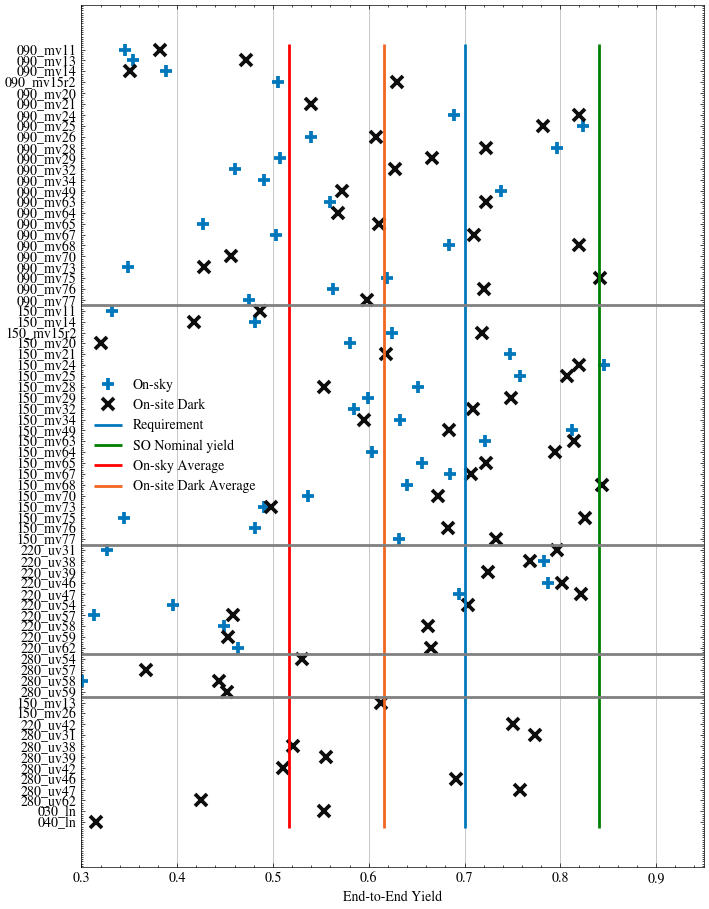

In [13]:


plt.style.use("apj-fullwidth")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 9))

#sns.boxplot(data=df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 3 / np.sin(np.deg2rad(50))),
#    x="yields", y="labels",
#)

sns.pointplot(
    data = means_df,
    x="yields",
    y="labels",
    label="On-sky",
    marker="+",
    linestyle="none",
)


sns.pointplot(
    data=toby_df,
    x="yields",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.05",
    zorder=2,
    label="On-site Dark",
)
"""
sns.pointplot(
    data=ptown_df,
    x="yields",
    y="labels",
    linestyle="none",
    marker="+",
    color="0.05",
    zorder=2,
    label="PTown Dark",
)
"""
plt.xlim(0.3, 0.95)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(0.7, ymin=ymin, ymax=ymax, label="Requirement", color=c_base)
plt.vlines(0.84, ymin=ymin, ymax=ymax, label="SO Nominal yield", color="green")

#plt.vlines(np.nanmean(df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 1 / np.sin(np.deg2rad(50))).yields),
#    ymin=ymin, ymax=ymax, label="On-Sky Average", color="black",
#)
plt.vlines(
    np.nanmean(means_df.yields),
    ymin=ymin, ymax=ymax,
    label="On-sky Average",
    color="red",
)
plt.vlines(
    np.nanmean(toby_df.yields),
    ymin=ymin,
    ymax=ymax,
    label="On-site Dark Average",
    color=c_goal,
)


pos_090 = len([label for label in set(df_yield.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len([label for label in set(df_yield.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df_yield.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df_yield.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220, pos_280], xmin=xmin, xmax=xmax, color="0.5")

plt.legend()

ax.xaxis.grid(True)
ax.set(xlabel="End-to-End Yield", ylabel="")

plt.savefig("../plts/aso_yield.png", dpi=600, bbox_inches="tight")
plt.savefig("../plts/aso_yield.pdf", dpi=600, bbox_inches="tight")

In [20]:
toby_df[toby_df.yields>1]

,labels,yields
60,280_uv38,447.924812


In [20]:
np.nanmean(df_yield.where((df_yield.labels == "090_mv73")).yields)

np.float64(0.3739648326715825)

In [ ]:
total_yield = []
pwvs = []
for time in times:
    ndets = 0
    narrays = 0
    for key in net_dict.keys():
        for sub_key in net_dict[key].keys():
            if freq not in sub_key:
                continue
            cur_obs = np.array(net_dict[key][sub_key]["obs"])
            for j in range(len(cur_obs)):
                if np.isclose(time, float(cur_obs[j].split("_")[1])):
                    cur_ndets = np.array(net_dict[key][sub_key]["ndets"])
                    cur_nets = np.array(net_dict[key][sub_key]["nets"])
                    # if cur_nets[j] <= 100 and cur_ndets[j] > 100: #very large nets are not real
                    ndets += cur_ndets[j]
                    narrays += 860
                    cur_el = np.array(net_dict[key][sub_key]["el"][j])
                    cur_pwv = pwv(cur_obs[j].split("_")[1])
    if narrays == 0:
        continue
    pwvs.append(cur_pwv / np.sin(np.deg2rad(cur_el)))
    total_yield.append(ndets / narrays)

df_total = pd.DataFrame({"yields": total_yield, "pwv": pwvs})